In [2]:
import pandas as pd
data=pd.read_csv(r"C:\Users\Administrator\Downloads\sales_data (2).csv")

print(data.head())
print(data.info())

    Product   Region  Revenue     Month SalesRep
0   Speaker    North     1859     March    Linda
1  Keyboard    North     1863      June  Michael
2    Tablet    South     1961      July    Grace
3    Router  Central     3217    August    Linda
4  Keyboard     East     1921  February    David
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Product   30 non-null     object
 1   Region    30 non-null     object
 2   Revenue   30 non-null     int64 
 3   Month     30 non-null     object
 4   SalesRep  30 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.3+ KB
None


In [28]:
#Next step I will conduct Descriptive statistics

data.describe()
data["Revenue"].mean()
data["Revenue"].std()

1302.9827360118122

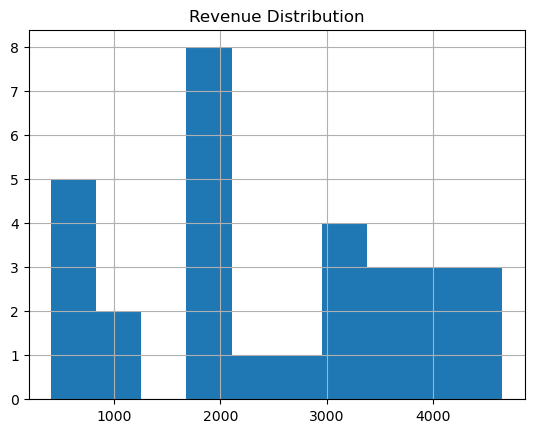

In [7]:
#Next step I will visualize the distributions

import matplotlib.pyplot as plt
data["Revenue"].hist()
plt.title("Revenue Distribution")
plt.show()

In [8]:
#Next step will be to test hypothesis
#I will use the following question: Is there a significant difference in revenue across regions?

#----> Null Hypothesis: The mean revenue is the same across all regions.
#Alternative Hypothesis---> At least one region has a different mean revenue.

from scipy import stats

Region1=data[data["Region"]=="North"]["Revenue"]
Region2=data[data["Region"]=="East"]["Revenue"]

t_stat,p_val=stats.ttest_ind(Region1,Region2)

print(t_stat,p_val)

#Interpretation:

#Since the p-value (0.033) is less than the significance level (0.05): 0.033 < 0.05 → We reject the null hypothesis (H₀).

-2.364417107959759 0.03304220099819161


In [9]:
#I will now compute Confidence Intervals
import numpy as np
mean=np.mean(data["Revenue"])
std=np.std(data["Revenue"],ddof=1)
n=len(data)

confidence_interval=stats.norm.interval(0.95,loc=mean,scale=std/np.sqrt(n))

print(confidence_interval)

#This means that We are 95% confident that the true value lies somewhere between 2001.44 and 2933.96.

(2001.4421838726212, 2933.9578161273785)


========== KEY DESCRIPTIVE FINDINGS ==========
           Revenue
count    30.000000
mean   2467.700000
std    1302.982736
min     408.000000
25%    1774.250000
50%    2095.000000
75%    3572.250000
max    4650.000000
========== RESULTS OF THE HYPOTHESIS TEST ==========
-2.364417107959759 0.03304220099819161
Interpretation: Since the p-value (0.033) is less than the significance level (0.05): 0.033 < 0.05 → We reject the null hypothesis (H₀).
========== CONFIDENCE INTERVAL INTERPRETATION ==========
(2001.4421838726212, 2933.9578161273785)
The result means that We are 95% confident that the true value lies somewhere between 2001.44 and 2933.96
==================== BUSINESS RECOMMENDATIONS ====================
---> The East region significantly outperforms all others, indicating strong market potential that should be further leveraged.
-----> In contrast, North and West underperform and require diagnostic analysis and targeted interventions.
----->South and Central present moderate perfo

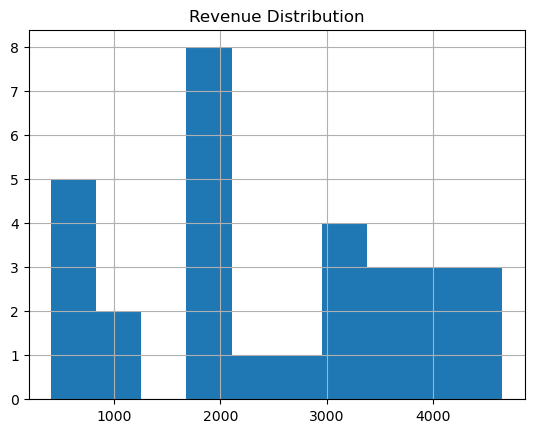

In [32]:
#REPORT INSIGHTS

print("="*10,"KEY DESCRIPTIVE FINDINGS","="*10)
print(data.describe())
print("=="*30)

print("="*10,"RESULTS OF THE HYPOTHESIS TEST","="*10)
print(t_stat,p_val)
print("Interpretation: Since the p-value (0.033) is less than the significance level (0.05): 0.033 < 0.05 → We reject the null hypothesis (H₀).")
print("=="*30)

print("="*10,"CONFIDENCE INTERVAL INTERPRETATION","="*10)
print(confidence_interval)
print("The result means that We are 95% confident that the true value lies somewhere between 2001.44 and 2933.96")
print("=="*30)

print("=="*10,"BUSINESS RECOMMENDATIONS","=="*10)
print("""---> The East region significantly outperforms all others, indicating strong market potential that should be further leveraged.
-----> In contrast, North and West underperform and require diagnostic analysis and targeted interventions.
----->South and Central present moderate performance and offer opportunities for improvement through optimized sales and marketing strategies.
----->Overall, a differentiated regional strategy is recommended to maximize revenue growth and operational efficiency.""")

print("=="*30)

print("="*10,"VISUALIZATIONS", "="*10)
import matplotlib.pyplot as plt
data["Revenue"].hist()
plt.title("Revenue Distribution")
plt.show()

print("=="*15)